In [ ]:
# !pip install scikit-image

In [15]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pandas.core.indexes 
sys.modules['pandas.indexes'] = pandas.core.indexes

from skimage.transform import resize
from tqdm import tqdm

Reference : https://www.kaggle.com/code/loozin/wm-811k-wafermap?utm_source=chatgpt.com

In [16]:
path = './data/LSWMD.pkl'

In [17]:
with open(path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

df = pd.DataFrame(data)

print(len(df))
print(df.head())

C:\Users\SKAX\AppData\Local\Temp\ipykernel_11908\2064552980.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1')


811457
                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  


In [18]:
# 라벨(failureType) 전처리
# 원본 데이터의 failureType은 [['Center']] 처럼 리스트 안에 있거나 비어있음
# 이를 일반 문자열로 변환하고, 라벨이 없는 데이터는 제외하는 과정
df['failureNum'] = df.failureType
df['trainTestNum'] = df.trianTestLabel

mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}

# 라벨 정보가 있는 데이터만 추출
df = df.drop(['waferIndex', 'dieSize', 'lotName'], axis=1) # 불필요한 컬럼 제거
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')

# 불량 유형별 개수 확인
print("\n<Class Distribution>")
print(df['failureType'].value_counts())


<Class Distribution>
failureType
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [19]:
def plot_wafer_maps(df, n_samples=3):
    """
    각 불량 유형별로 n_samples개씩 샘플링하여 시각화하는 함수
    """
    failure_types = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
    
    fig, ax = plt.subplots(len(failure_types), n_samples, figsize=(n_samples*3, len(failure_types)*3))
    
    for i, f_type in enumerate(failure_types):
        # 해당 불량 유형 데이터 필터링
        type_df = df[df['failureType'] == f_type]
        
        # 랜덤 샘플링
        if len(type_df) >= n_samples:
            samples = type_df.sample(n_samples)['waferMap'].values
        else:
            samples = type_df['waferMap'].values
            
        for j in range(n_samples):
            if j < len(samples):
                # 웨이퍼 맵 이미지 출력
                # cmap='inferno': 0(보라/검정-배경), 1(주황-정상), 2(노랑-불량) 등으로 표현됨
                # 직관적인 색상을 위해 사용자 정의 cmap을 써도 좋음
                ax[i, j].imshow(samples[j], cmap='inferno') 
                ax[i, j].set_title(f"{f_type}", fontsize=10)
                ax[i, j].axis('off')
            else:
                ax[i, j].axis('off')
                
    plt.tight_layout()
    plt.show()

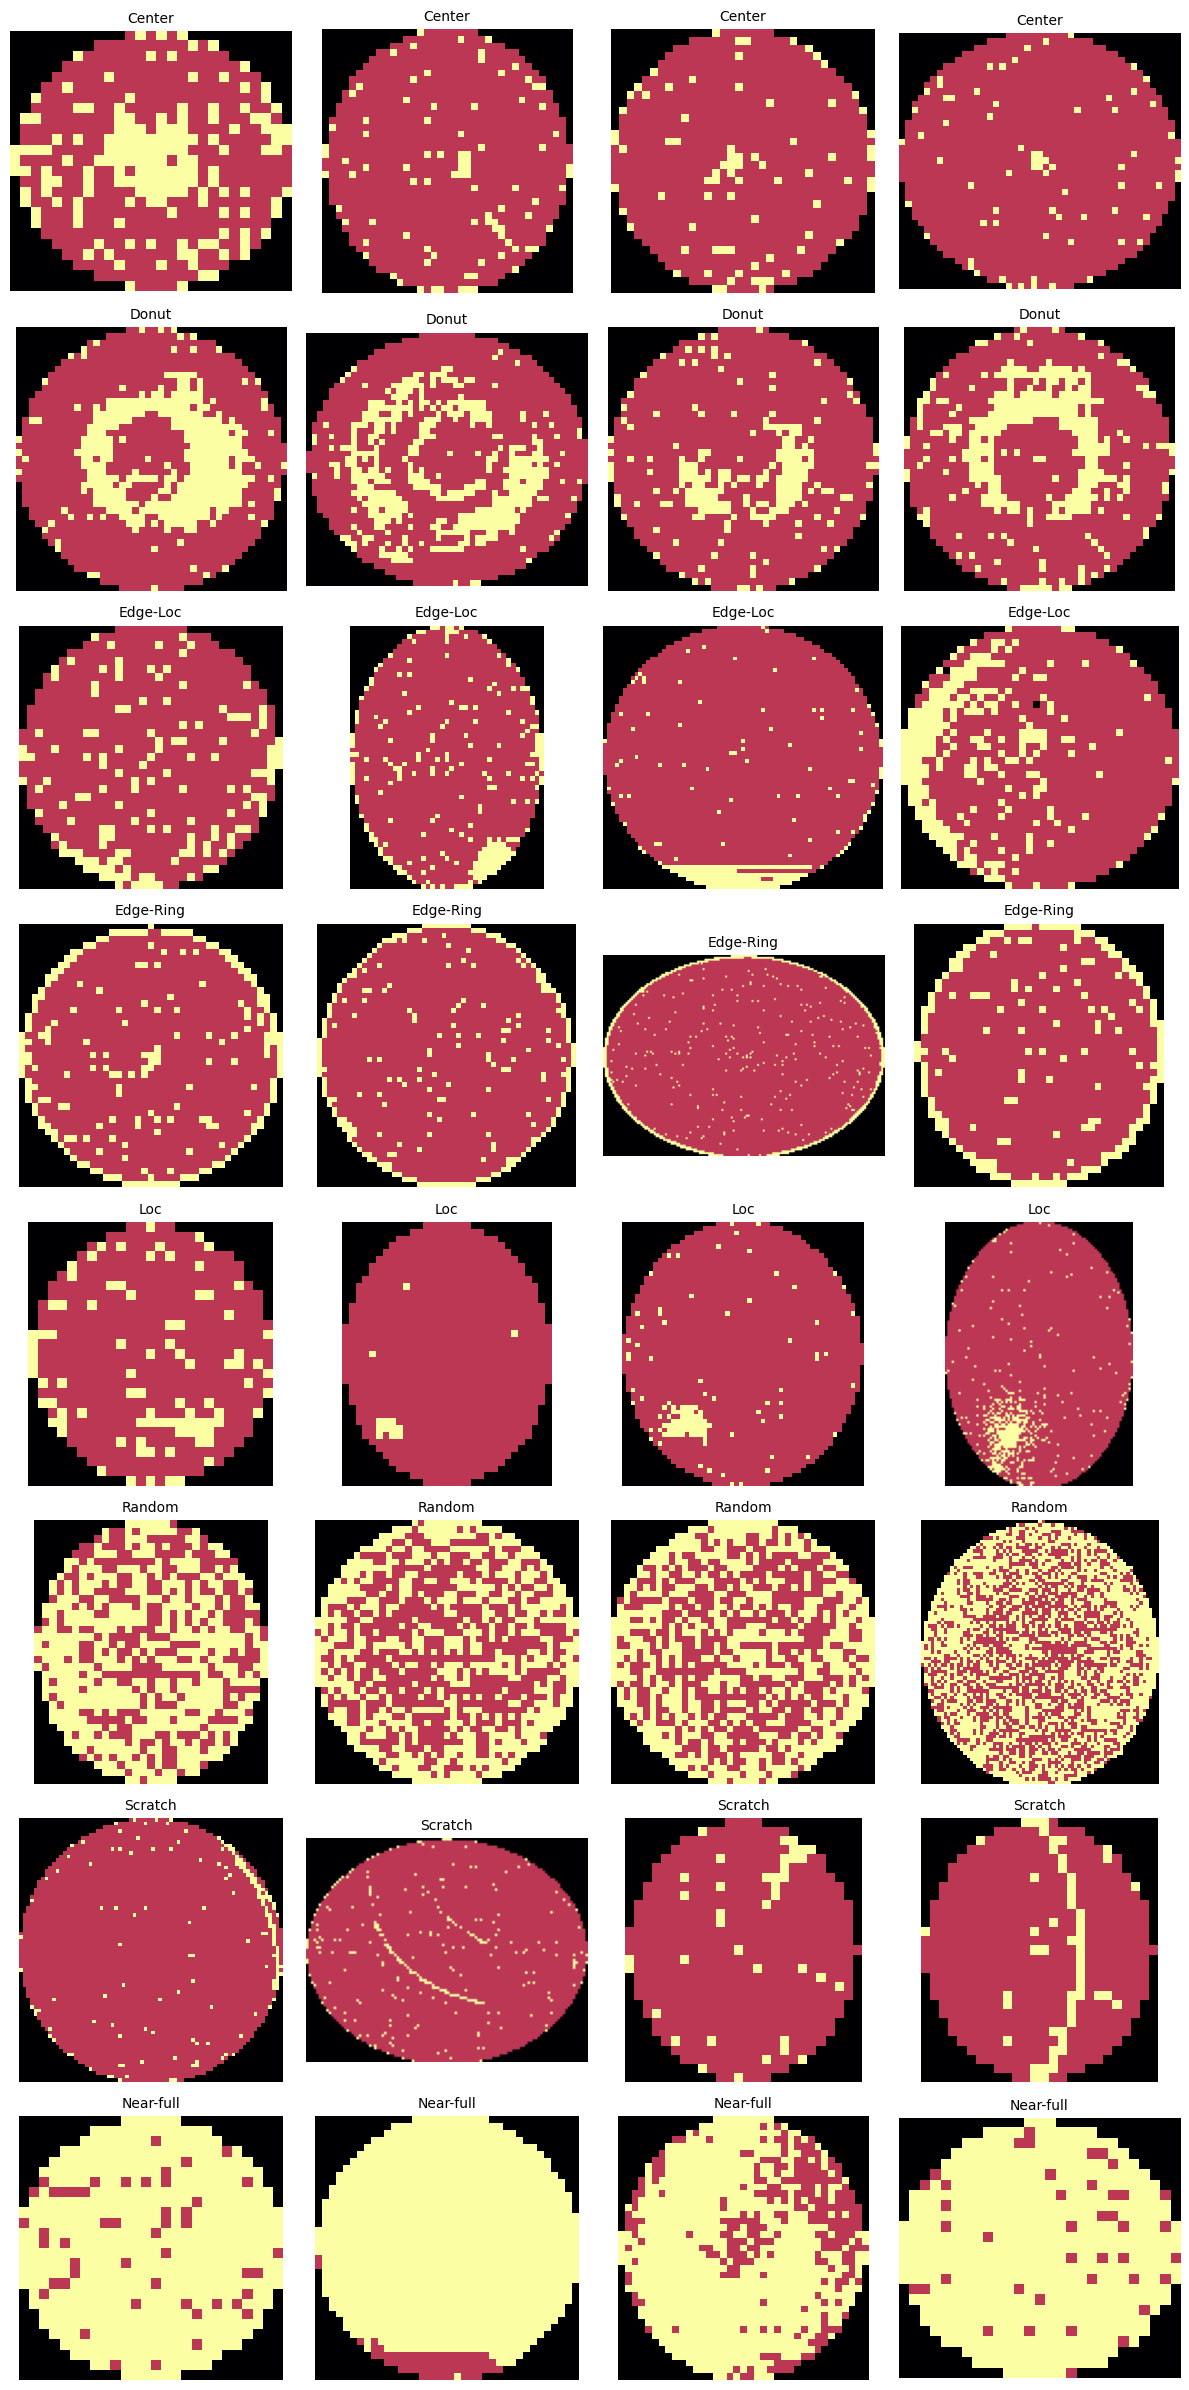

In [20]:
plot_wafer_maps(df, n_samples=4)

In [21]:
# CNN 입력 처리 위한 전처리 (Resize) 
# 웨이퍼크기가 제각각이라 고정된 크기 (64*64)로 맞춤 

def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    CNN 입력용으로 이미지 크기를 통일하는 함수
    OpenCV의 resize 등을 사용해도 무방
    """
    # 웨이퍼 맵을 target_size로 변환 (Nearest Neighbor 보간법 권장: 0,1,2 값을 유지하기 위해)
    # 다만, skimage resize는 기본적으로 float로 반환하므로 주의 필요
    resized_map = resize(wafer_map, target_size, anti_aliasing=False, preserve_range=True, order=0)
    
    # 0, 1, 2 정수값 유지
    return resized_map.astype(int)

In [22]:
# 테스트: 첫 번째 데이터 변환 확인
sample_wafer = df.iloc[0]['waferMap']
resized_wafer = preprocess_wafer_map(sample_wafer)

print(f"\nOriginal shape: {sample_wafer.shape}")
print(f"Resized shape: {resized_wafer.shape}")


Original shape: (45, 48)
Resized shape: (64, 64)


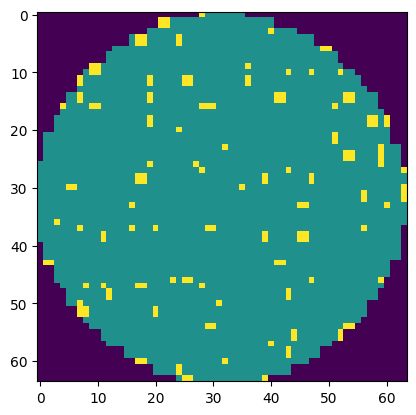

In [23]:
plt.imshow(resized_wafer)

# Baseline

In [26]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [29]:
# tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


print("\n리사이징 및 변환 시작 ...")
resized_list = [preprocess_wafer_map(x) for x in tqdm(df_reduced['waferMap'])]

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape}") 
print(f"메모리 사용량: {X.nbytes / 1024 / 1024:.2f} MB")

원본 데이터 크기: 811457
30519장으로 축소 (불량: 25519, 정상: 5000)

리사이징 및 변환 시작 ...


100%|██████████| 30519/30519 [00:04<00:00, 7449.75it/s]



=== 최종 결과 확인 ===
최종 X 데이터 Shape: (30519, 1, 64, 64)
메모리 사용량: 476.86 MB


In [30]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [31]:
# data set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (24415, 1, 64, 64), Test: (6104, 1, 64, 64)


In [32]:
# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images) # Float형 텐서 변환
        self.labels = torch.LongTensor(labels)  # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [41]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, y_train)
test_dataset = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 382, Test batches: 96


1. CNN 아키텍처 개선

- Conv → BatchNorm → ReLU → Pool 구조
- CNN depth 증가 (Conv block 추가), 레이어 깊이 2 → 3 Layer
- 채널 수 점진적 증가 (예: 32 → 64 → 128)
- Dropout 추가 (FC 또는 Conv 이후)

In [43]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        
        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 1, 64, 64)
        # Layer 1: 입력 (1, 64, 64) -> 출력 (32, 32, 32)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # 학습 안정화 및 속도 향상
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Layer 2: 출력 (64, 16, 16)
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Layer 3: 출력 (128, 8, 8)
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 고수준 feature 정제용 Conv
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Feature-level regularization
            nn.Dropout2d(0.2)
        )
        
        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가 등)
        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            # FC 차원 축소 (과적합 방지)
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            # Dropout 강도 완화 (underfitting 방지)
            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로, 
        # 모델 끝에 Softmax를 붙이지 않습니다.

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.fc_layers(x)
        return x
    
num_classes = len(df_reduced['failureType'].unique())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN(num_classes=num_classes).to(device)
print(model)
print(f"클래스 수: {num_classes}, 장치: {device}")

BaselineCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPoo

2. Training Strategy 개선

- Optimizer: Adam
- Learning Rate Scheduler: CosineAnnealingLR
- 학습 안정성 증가

In [47]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Cosine Annealing LR Scheduler
# → 후반부 학습을 미세 조정하여 Test Accuracy 상승
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,      # 🔧 [중요] 전체 epoch 수와 맞추기
    eta_min=1e-5
)

def train_model(model, train_loader, criterion, optimizer, scheduler, epochs=10):
    train_losses = []
    
    for epoch in range(epochs):
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)

        # Epoch 종료 후 LR 업데이트
        scheduler.step()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
        
    return train_losses

# 학습 실행
print("Starting Training...")
history = train_model(model, train_loader, criterion, optimizer, scheduler, epochs=10)

Starting Training...
Epoch [1/10], Loss: 0.4734, Accuracy: 83.78%
Epoch [2/10], Loss: 0.4228, Accuracy: 85.26%
Epoch [3/10], Loss: 0.3971, Accuracy: 86.24%
Epoch [4/10], Loss: 0.3682, Accuracy: 87.17%
Epoch [5/10], Loss: 0.3478, Accuracy: 87.88%
Epoch [6/10], Loss: 0.3254, Accuracy: 88.53%
Epoch [7/10], Loss: 0.3012, Accuracy: 89.72%
Epoch [8/10], Loss: 0.2901, Accuracy: 89.97%
Epoch [9/10], Loss: 0.2662, Accuracy: 90.92%
Epoch [10/10], Loss: 0.2520, Accuracy: 91.37%



Final Test Accuracy: 89.76%


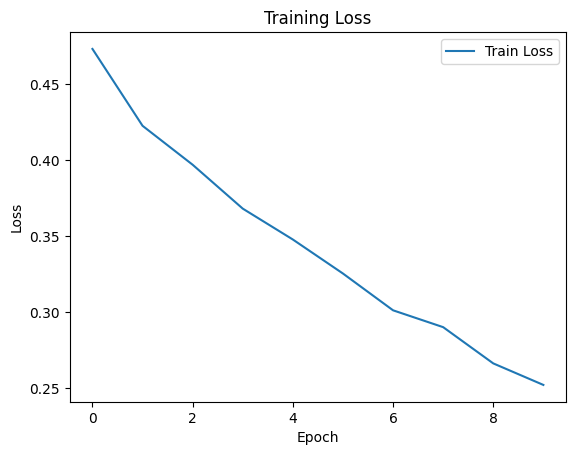

In [49]:
# 테스트 데이터 평가 함수
def evaluate_model(model, test_loader):
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    return acc

# 최종 성능 확인
test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# 학습 Loss 시각화
plt.plot(history, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

3. 최종 결과

- Training Loss: 지속적 감소
- Train Accuracy: 91.37%
- Final Test Accuracy: 89.76%

4. 개선 효과

- Train / Validation 차이 과도하지 않음
- 과적합 없이 일반화 성능 향상
- Vanilla 대비 명확한 개선 확인

---
End of Documents